In [21]:
import os

In [26]:
os.chdir('/home/witoslaw/data/diffTSS')
os.getcwd()

'/home/witoslaw/data/diffTSS'

In [23]:
from EPInformer.models import EPInformer_v2, enhancer_predictor_256bp
from scripts.utils import prepare_input, prepare_hd5_input, FastaStringExtractor, one_hot_encode
from sklearn.preprocessing import StandardScaler
import scripts.utils_forTraining as train
import kipoiseq
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from tqdm import tqdm
import torch
from torch.utils.data import Subset, Dataset
import h5py
import matplotlib.pyplot as plt

In [29]:
os.listdir('.')

['ABC-multiTSS_nominated',
 'CRISPRi-FlowFISH_Fulco2019',
 'GM12878_K562_18377_gene_expr_fromXpresso.csv',
 'GM12878_enhancer_gene_links_100kb.hg38.tsv',
 'GM12878_enhancer_promoter_encoding.hg38.h5',
 'GM12878_enhancer_promoter_encoding.rna_embedding.hg38.h5',
 'GM12878_enhancer_promoter_encoding.rna_encoding.hg38.h5',
 'GeneList_GM12878.txt',
 'GeneList_K562.txt',
 'K562_enhancer_gene_links_100kb.hg38.tsv',
 'K562_enhancer_promoter_encoding.hg38.h5',
 'K562_enhancer_promoter_encoding.rna_embedding.hg38.h5',
 'K562_enhancer_promoter_encoding.rna_encoding.hg38.h5',
 'RNASeq_bw',
 'RNA_CAGE.txt',
 'command.CAGE.sh',
 'command.RNAseq.sh',
 'command.Xpresso.sh',
 'download_EPInformer_training_data.sh',
 'download_abc_data.sh',
 'hg38.fa',
 'hg38.fa.fai',
 'leave_chrom_out_crossvalidation_split_18377genes.csv',
 'mRNA_halflife_features.csv',
 'replaceID.Xpresso.py']

In [31]:
enhancer_gene_k562_100kb = pd.read_csv('./K562_enhancer_gene_links_100kb.hg38.tsv', sep='\t')
gene_k562_tss = pd.read_csv('./ABC-multiTSS_nominated/K562/Neighborhoods/GeneList.txt', sep='\t')[['name', 'Ensembl_ID', 'chr', 'tss', 'strand', 'H3K27ac.RPM.TSS1Kb', 'DHS.RPM.TSS1Kb']]
gene_k562_tss['ENSID'] = gene_k562_tss['Ensembl_ID']

enhancer_gene_k562_100kb_includeNoEnhancerGene = enhancer_gene_k562_100kb.merge(gene_k562_tss, left_on='TargetGeneEnsembl_ID', right_on='Ensembl_ID', how='right', suffixes=['', '_gene']).reset_index()

gene_list = list(gene_k562_tss['ENSID'])

rna_df_K562 = pd.read_csv('./RNASeq_bw/K562.minus.ENCFF528VFJ.coverage.txt', header=None, sep='\t')

In [32]:
rna_values = np.array(rna_df_K562[[9]]).flatten()
rna_values.shape

(9602716,)

In [33]:
rna_values[np.where(rna_values < 10)].shape[0] / rna_values.shape[0]

0.9893172931491465

(array([9.568483e+06, 1.501700e+04, 8.200000e+03, 5.217000e+03,
        2.312000e+03, 1.392000e+03, 6.340000e+02, 2.730000e+02,
        3.190000e+02, 3.120000e+02, 1.450000e+02, 7.700000e+01,
        1.000000e+02, 4.000000e+01, 2.400000e+01, 3.800000e+01,
        2.100000e+01, 1.000000e+01, 8.000000e+00, 5.000000e+00,
        1.000000e+00, 3.000000e+00, 3.000000e+00, 1.200000e+01,
        1.300000e+01, 2.000000e+00, 9.000000e+00, 1.300000e+01,
        1.000000e+01, 2.300000e+01]),
 array([4.40000000e-04, 4.11247587e+01, 8.22490773e+01, 1.23373396e+02,
        1.64497715e+02, 2.05622033e+02, 2.46746352e+02, 2.87870671e+02,
        3.28994989e+02, 3.70119308e+02, 4.11243627e+02, 4.52367945e+02,
        4.93492264e+02, 5.34616583e+02, 5.75740901e+02, 6.16865220e+02,
        6.57989539e+02, 6.99113857e+02, 7.40238176e+02, 7.81362495e+02,
        8.22486813e+02, 8.63611132e+02, 9.04735451e+02, 9.45859769e+02,
        9.86984088e+02, 1.02810841e+03, 1.06923273e+03, 1.11035704e+03,
        1.

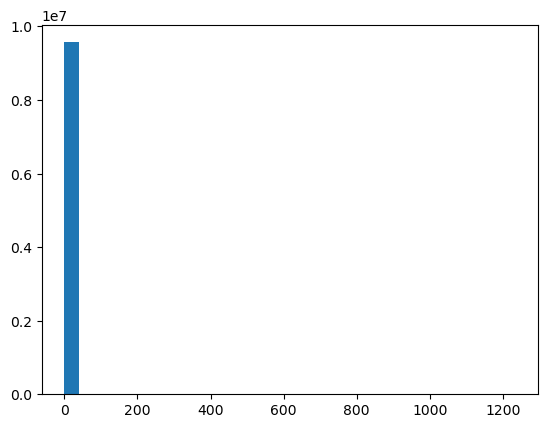

In [34]:
plt.hist(rna_values, bins=30)

(array([5389491., 1132652.,  538380.,  404688.,  221985.,  167236.,
         162335.,  106133.,  112508.,   90103.,   77787.,   66089.,
          58240.,   50831.,   53045.,   38623.,   45935.,   35636.,
          38855.,   33714.,   35118.,   36466.,   35665.,   34716.,
          36862.,   37932.,   41569.,   49138.,   63440.,  407544.]),
 array([4.39999972e-04, 3.37586666e-02, 6.70773333e-02, 1.00396000e-01,
        1.33714667e-01, 1.67033333e-01, 2.00352000e-01, 2.33670667e-01,
        2.66989333e-01, 3.00308000e-01, 3.33626667e-01, 3.66945333e-01,
        4.00264000e-01, 4.33582667e-01, 4.66901333e-01, 5.00220000e-01,
        5.33538667e-01, 5.66857333e-01, 6.00176000e-01, 6.33494667e-01,
        6.66813333e-01, 7.00132000e-01, 7.33450667e-01, 7.66769333e-01,
        8.00088000e-01, 8.33406667e-01, 8.66725333e-01, 9.00044000e-01,
        9.33362667e-01, 9.66681333e-01, 1.00000000e+00]),
 <BarContainer object of 30 artists>)

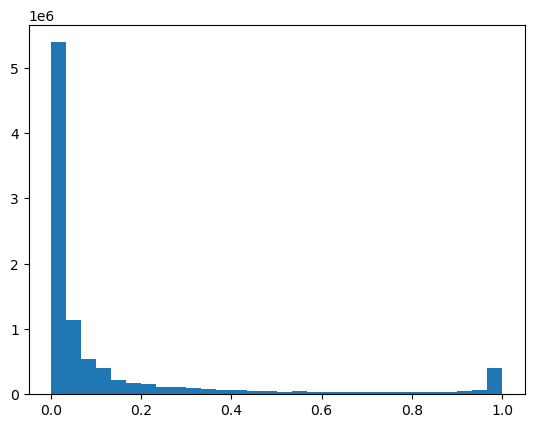

In [35]:
plt.hist(np.tanh(rna_values), bins=30)

(array([6522139.,  943060.,  389059.,  267960.,  168983.,  139853.,
         107736.,   84386.,   73751.,   54770.,   53729.,   45102.,
          41474.,   39499.,   34730.,   31557.,   33590.,   27304.,
          30028.,   26949.,   27016.,   24833.,   25349.,   25495.,
          24830.,   26165.,   29853.,   31747.,   40868.,  230901.]),
 array([0.50011 , 0.516773, 0.533436, 0.550099, 0.566762, 0.583425,
        0.600088, 0.616751, 0.633414, 0.650077, 0.66674 , 0.683403,
        0.700066, 0.716729, 0.733392, 0.750055, 0.766718, 0.783381,
        0.800044, 0.816707, 0.83337 , 0.850033, 0.866696, 0.883359,
        0.900022, 0.916685, 0.933348, 0.950011, 0.966674, 0.983337,
        1.      ]),
 <BarContainer object of 30 artists>)

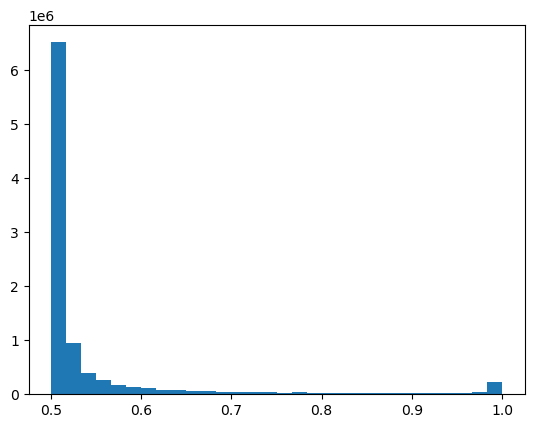

In [36]:
plt.hist(1/ (1 + np.exp(-rna_values)), bins=30)

(array([8.122195e+06, 5.618320e+05, 2.575440e+05, 1.690280e+05,
        1.174130e+05, 8.802800e+04, 6.517800e+04, 5.067500e+04,
        3.606600e+04, 2.956400e+04, 2.114000e+04, 1.596000e+04,
        1.247100e+04, 9.709000e+03, 7.186000e+03, 5.842000e+03,
        5.414000e+03, 5.094000e+03, 4.894000e+03, 4.713000e+03,
        4.796000e+03, 3.304000e+03, 2.070000e+03, 1.196000e+03,
        5.650000e+02, 4.860000e+02, 1.750000e+02, 8.200000e+01,
        1.800000e+01, 7.800000e+01]),
 array([1.91047545e-04, 1.03237079e-01, 2.06283111e-01, 3.09329143e-01,
        4.12375175e-01, 5.15421206e-01, 6.18467238e-01, 7.21513270e-01,
        8.24559302e-01, 9.27605333e-01, 1.03065137e+00, 1.13369740e+00,
        1.23674343e+00, 1.33978946e+00, 1.44283549e+00, 1.54588152e+00,
        1.64892756e+00, 1.75197359e+00, 1.85501962e+00, 1.95806565e+00,
        2.06111168e+00, 2.16415771e+00, 2.26720375e+00, 2.37024978e+00,
        2.47329581e+00, 2.57634184e+00, 2.67938787e+00, 2.78243390e+00,
        2.

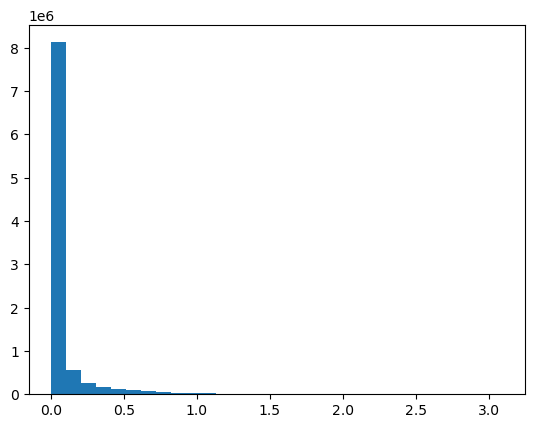

In [37]:
plt.hist(np.log10(rna_values+1), bins=30)

In [46]:
def transform(transform, data):
        if transform == 'log10':
            return np.log10(data + 1)
        elif transform == 'tanh':
            return np.tanh(data)
        elif transform == 'sigmoid':
            return 1 / (1 + np.exp(-data))

In [38]:
gene_enhancer_table = enhancer_gene_k562_100kb_includeNoEnhancerGene
promoter_signals = gene_k562_tss
cells = 'K562'
num_features = 3
rna_method = 'one-hot'
rna_df=rna_df_K562

In [39]:
gene_enhancer_table

,level_0,index,chr,start,end,name,class,activity_base,activity_base_enh,activity_base_squared_enh,...,CellType,hic_contact_squared,name_gene,Ensembl_ID,chr_gene,tss,strand,H3K27ac.RPM.TSS1Kb,DHS.RPM.TSS1Kb,ENSID
0,0,98.0,chr1,9962.0,10783.0,intergenic|chr1:9962-10783,intergenic,28.061392,28.061392,787.441721,...,K562,0.000258,WASH7P,ENSG00000310526,chr1,29359,-,20.624191,5.158874,ENSG00000310526
1,1,197.0,chr1,16019.0,16519.0,genic|chr1:16019-16519,genic,0.946879,0.946879,0.896580,...,K562,0.000553,WASH7P,ENSG00000310526,chr1,29359,-,20.624191,5.158874,ENSG00000310526
2,2,395.0,chr1,115483.0,115983.0,intergenic|chr1:115483-115983,intergenic,10.939918,10.939918,119.681806,...,K562,0.000012,WASH7P,ENSG00000310526,chr1,29359,-,20.624191,5.158874,ENSG00000310526
3,3,494.0,chr1,118375.0,118875.0,intergenic|chr1:118375-118875,intergenic,4.546150,4.546150,20.667480,...,K562,0.000011,WASH7P,ENSG00000310526,chr1,29359,-,20.624191,5.158874,ENSG00000310526
4,4,593.0,chr1,119430.0,119930.0,intergenic|chr1:119430-119930,intergenic,7.064581,7.064581,49.908305,...,K562,0.000011,WASH7P,ENSG00000310526,chr1,29359,-,20.624191,5.158874,ENSG00000310526
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
742131,742131,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,ENSG00000288057,ENSG00000288057,chrY,21456216,-,0.000000,0.000000,ENSG00000288057
742132,742132,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,RBMY2FP,ENSG00000290336,chrY,22308884,+,0.000000,0.000000,ENSG00000290336
742133,742133,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,DAZ3,ENSG00000187191,chrY,24813393,-,0.000000,0.000000,ENSG00000187191
742134,742134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,DAZ4,ENSG00000205916,chrY,24833917,+,0.000000,0.000000,ENSG00000205916


In [40]:
mRNA_feauture = pd.read_csv('./RNA_CAGE.txt', sep='\t', index_col='ENSID')
promoter_signals['PromoterActivity'] = np.sqrt(promoter_signals['H3K27ac.RPM.TSS1Kb']*promoter_signals['DHS.RPM.TSS1Kb'])
promoter_signals.set_index('ENSID', inplace=True)
mRNA_feats = ['UTR5LEN_log10zscore',
   'CDSLEN_log10zscore', 'INTRONLEN_log10zscore', 'UTR3LEN_log10zscore',
   'UTR5GC', 'CDSGC', 'UTR3GC', 'ORFEXONDENSITY']
PE_code_list = []
#PE_feat_list = []
PE_distance_list = []
PE_activity_list = []
PE_contact_list = []
mRNA_promoter_list = []
PE_links_list = []

In [41]:
gene = gene_list[0]
gene_df = gene_enhancer_table[gene_enhancer_table['ENSID'] == gene]
if rna_encoding:
    gene_rna_df = rna_df[rna_df[3] == gene]
    
gene_enhancer_df = gene_df
fasta_path = './hg38.fa'
max_n_enhancer = 60
max_distanceToTSS = 100_000
max_seq_len=2000
add_flanking=False
rna_df = gene_rna_df.copy()

fasta_extractor = FastaStringExtractor(fasta_path)
gene_pe = gene_enhancer_df.sort_values(by='distance')
row_0 = gene_pe.iloc[0]
gene_ensid=row_0['TargetGeneEnsembl_ID']
gene_name = row_0['TargetGene']
gene_tss = row_0['TargetGeneTSS']
chrom = row_0['chr']
if row_0['TargetGeneTSS'] != row_0['TargetGeneTSS']:
    gene_tss = row_0['tss']
    gene_name = row_0['name_gene']
    chrom = row_0['chr_gene']
target_interval = kipoiseq.Interval(chrom, int(gene_tss-max_seq_len/2), int(gene_tss+max_seq_len/2))
promoter_seq = fasta_extractor.extract(target_interval)
promoter_code = one_hot_encode(promoter_seq)

In [42]:
promoter_code

array([[1, 0, 0, 0],
       [0, 0, 0, 1],
       [0, 0, 0, 1],
       ...,
       [0, 0, 0, 1],
       [1, 0, 0, 0],
       [1, 0, 0, 0]], dtype=uint8)

In [60]:
if rna_method == 'one-hot':
    gene_len = row_0['end'] - row_0['start']
    rna_signal = rna_df[[9]]
    rna_df = rna_df[(rna_df[7] >= target_interval.start) & (rna_df[8] <= target_interval.end)]
    new_index = rna_df[7].values - target_interval.start
    rna_signal = rna_signal.set_index(new_index).reindex(list(range(0,max_seq_len)), fill_value=0)
    
    #rna_signal = rna_signal.apply(lambda x: np.exp(-x))
    #promoter_code = np.concatenate((promoter_code, rna_signal), axis=1)     
    
#promoter_code
np.array(rna_signal)

array([[0.     ],
       [0.18965],
       [0.18965],
       ...,
       [0.01894],
       [0.01894],
       [0.01894]])

In [56]:
promoter_code * np.array(transform('sigmoid', rna_signal))

array([[0.5       , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.5472709 ],
       [0.        , 0.        , 0.        , 0.5472709 ],
       ...,
       [0.        , 0.        , 0.        , 0.50473486],
       [0.50473486, 0.        , 0.        , 0.        ],
       [0.50473486, 0.        , 0.        , 0.        ]])

In [ ]:
promoter_code[:, 4].min()

In [ ]:
if rna_embedding:
    rna_df = np.concatenate([rna_df.reshape(1, 125), np.zeros([60, 125])])
enhancers_code = np.zeros((max_n_enhancer, max_seq_len, 4))
enhancer_activity = np.zeros(max_n_enhancer)
enhancer_distance = np.zeros(max_n_enhancer)
enhancer_contact = np.zeros(max_n_enhancer)
# set distance threshold
gene_pe = gene_pe[(gene_pe['distance'] > max_seq_len/2)&(gene_pe['distance'] <= max_distanceToTSS)]
e_i = 0
gene_element_pair = []
for idx, row in gene_pe.iterrows():
    if row['TargetGene'] != row['TargetGene']:
        break
    if pd.isna(row['start']):
        continue
    if e_i >= max_n_enhancer:
        break
    enhancer_start = int(row['start'])
    enhancer_end = int(row['end'])
    enhancer_center = int((row['start'] + row['end'])/2)
    enhancer_len = enhancer_end - enhancer_start
    # put sequence at the center
    if add_flanking:
        enhancer_target_interval = kipoiseq.Interval(chrom, enhancer_center-int(max_seq_len/2), enhancer_center+int(max_seq_len/2))
        enhancers_code[e_i][:] = one_hot_encode(fasta_extractor.extract(enhancer_target_interval))
    else:
        # enhancers_signal = np.zeros((max_n_enhancer, max_seq_len))
        if enhancer_len > max_seq_len:
            enhancer_target_interval = kipoiseq.Interval(chrom, enhancer_center-int(max_seq_len/2), enhancer_center+int(max_seq_len/2))
            enhancers_code[e_i][:] = one_hot_encode(fasta_extractor.extract(enhancer_target_interval))
        else:
            code_start = int(max_seq_len/2)-int(enhancer_len/2)
            enhancer_target_interval = kipoiseq.Interval(chrom, enhancer_start, enhancer_end)
            enhancers_code[e_i][code_start:code_start+enhancer_len] = one_hot_encode(fasta_extractor.extract(enhancer_target_interval))
    # put sequence from the start
    enhancer_activity[e_i] = row['activity_base']
    enhancer_distance[e_i] = row['distance']
    enhancer_contact[e_i] = row['hic_contact']
    gene_element_pair.append([gene_name, row['name']])
    e_i += 1

In [ ]:
enhancers_code[0]

In [ ]:
# print(promoter_signals.shape, enhancers_signal.shape)
if rna_encoding:
    enhancers_code = np.concatenate((enhancers_code, np.zeros((max_n_enhancer, max_seq_len, 1))), axis=2)
    pe_code = np.concatenate([promoter_code[np.newaxis,:], enhancers_code], axis=0, dtype=np.float32)
else:
    pe_code = np.concatenate([promoter_code[np.newaxis,:], enhancers_code], axis=0)
gene_element_pair = pd.DataFrame(gene_element_pair, columns=['gene', 'element'])
if rna_embedding:
    return pe_code, enhancer_activity, enhancer_distance, enhancer_contact, gene_name, gene_element_pair, rna_df
return pe_code, enhancer_activity, enhancer_distance, enhancer_contact, gene_name, gene_element_pair


contact_list = np.concatenate([[0], contact_list])
distance_list = np.concatenate([[0], distance_list/1000])
activity_list = np.concatenate([[0], activity_list])
# activity_list = np.log10(0.1+activity_list)
contact_list = np.log10(1+contact_list)
try:
    gene_mRNA_feature = mRNA_feauture.loc[gene, mRNA_feats]
except KeyError:
    dummy_mRNA_feature = pd.DataFrame(columns=mRNA_feats)
    dummy_mRNA_feature.loc[0] = [None]*len(mRNA_feats)
    gene_mRNA_feature = dummy_mRNA_feature.loc[0]
mRNA_promoter_feat = np.array(list(gene_mRNA_feature.values) + [promoter_signals.loc[gene, 'PromoterActivity']])
#if num_features == 1:
#    PE_feat = distance_list[:,np.newaxis]
#    mRNA_promoter_feat = np.array(list(gene_mRNA_feature.values) + [0])
#elif num_features == 2:
#    PE_feat = np.concatenate([distance_list[:,np.newaxis], activity_list[:,np.newaxis], ],axis=-1)
#else:
#    PE_feat = np.concatenate([distance_list[:,np.newaxis], contact_list[:,np.newaxis], activity_list[:,np.newaxis], ],axis=-1)
# print(gene_name, PE_code.shape, PE_feat.shape, mRNA_promoter_feat.shape)
PE_code_list.append(PE_code)
#PE_feat_list.append(PE_feat)
PE_distance_list.append(distance_list)
PE_activity_list.append(activity_list)
PE_contact_list.append(contact_list)
mRNA_promoter_list.append(mRNA_promoter_feat)
PE_links_list.append(PE_links)